In [ ]:
# To switch to R, we use the `%%R` magic command. (This comment is now redundant as we are already in R kernel)

if (!requireNamespace("googledrive", quietly = TRUE)) {
    install.packages("googledrive", repos = "https://cloud.r-project.org/")
}

In [ ]:
library(googledrive)
drive_auth()

Is it OK to cache OAuth access credentials in the folder ~/.cache/gargle
between R sessions?
1: Yes
2: No


Selection: Yes


Enter a number between 1 and 2, or enter 0 to exit.


Selection: 1


Please point your browser to the following url: 

https://accounts.google.com/o/oauth2/v2/auth?client_id=603366585132-frjlouoa3s2ono25d2l9ukvhlsrlnr7k.apps.googleusercontent.com&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email&redirect_uri=https%3A%2F%2Fwww.tidyverse.org%2Fgoogle-callback%2F&response_type=code&state=fec98adc40cabf2ebdf1e9e0c9a17150&access_type=offline&prompt=consent



Enter authorization code: eyJjb2RlIjoiNC8wQWVvV3VNX3ctNV9fbTI3dTJ0WVJHMjJpNkVadFoxd0pHdDJTVDZGeVhZX3lWdDE2SDdfOWN0Tk55VVMyWm1nSjJwUERGUSIsInN0YXRlIjoiZmVjOThhZGM0MGNhYmYyZWJkZjFlOWUwYzlhMTcxNTAifQ==


In [ ]:
files <- drive_find(n = 5)

if (nrow(files) > 0) {
  print(head(files))
} else {
  print("No files found or an empty result was returned.")
}

# A dribble: 5 × 3
  name             id                                drive_resource   
  <chr>            <drv_id>                          <list>           
1 Untitled6.ipynb  1Xgh8myQ3h7Ji7glaBefxC7MhnGaoEpRS <named list [46]>
2 GSE183276        1omXDqJsoqQnOy0Op6_kIr7Vz57kvxRhL <named list [37]>
3 Working_geo_data 1_8TC5RntQ3w_28jYMzDW66gpHp-AXV68 <named list [37]>
4 R_scRNA.ipynb    1cTS7wUp1GjltyJ3LH2n4GJiDbrtrYgGN <named list [46]>
5 Colab Notebooks  1-6yQaTnQBjBCCtg05V6bQprwqnmjZn77 <named list [37]>


### Set Working Directory

To set the working directory, we use the `setwd()` function in R. Please replace `"/path/to/your/directory"` with the actual path you wish to use.

In [ ]:
dir_path <- "/content/drive/My Drive/Working_geo_data/GSE183276"

if (!dir.exists(dir_path)) {
  dir.create(dir_path, recursive = TRUE)
  print(paste0("Directory '", dir_path, "' created."))
} else {
  print(paste0("Directory '", dir_path, "' already exists."))
}

setwd(dir_path) # Set the working directory
print(paste0("Working directory set to: ", getwd()))

[1] "Directory '/content/drive/My Drive/Working_geo_data/GSE183276' created."
[1] "Working directory set to: /content/drive/My Drive/Working_geo_data/GSE183276"


In [ ]:
list.files()

character(0)

In [ ]:
Note: To access files via path (e.g., `/content/drive/My Drive/...`), click the Folder icon on the left sidebar and select **Mount Drive**. The Python code previously used does not work in an R kernel.

ERROR: Error in parse(text = input): <text>:1:10: unexpected symbol
1: Note: To access
             ^


In [ ]:
# Use the googledrive package to list files inside the specific folder ID
# The ID was identified from your previous drive_find() results
folder_id <- "1omXDqJsoqQnOy0Op6_kIr7Vz57kvxRhL"
drive_ls(as_id(folder_id))

name                                                                               
1 GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Seurat_03282022.h5Seurat          
2 GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Metadata_Field_Descriptions.txt.gz
3 GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Metadata_03282022.txt.gz          
4 GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Counts_03282022.RDS.gz            
  id                                drive_resource <NA>     <NA> 
1 1x_DB5JFUHaVPagLUbSxzAKEMaYD3_gwx drive#file     h5Seurat FALSE
2 1YRiHS2z4VOtHXFTGPVqimq-QiDNY9Fl3 drive#file     h5Seurat FALSE
3 1-WJlcxC4S-3EI28_g9kib1z0JOgjqIxu drive#file     h5Seurat FALSE
4 1jqj0YyrNF1yxB-HO2aCm79h2WWEmWUXm drive#file     h5Seurat FALSE
  <NA>                             <NA> <NA> <NA>                    
1 ff583ad834eaae3baa8dd69914a34e2f TRUE TRUE application/octet-stream
2 ff583ad834eaae3baa8dd69914a34e2f TRUE TRUE application/octet-stream
3 ff583ad834eaae3baa8dd69914a34e2f TRUE TRUE application/octet-stream
4 ff583ad834eaae3baa8dd69914a34e2f TRUE TRUE application/octet-stream
  <NA>                             
1 1omXDqJsoqQnOy0Op6_kIr7Vz57kvxRhL
2 1omXDqJsoqQnOy0Op6_kIr7Vz57kvxRhL
3 1omXDqJsoqQnOy0Op6_kIr7Vz57kvxRhL
4 1omXDqJsoqQnOy0Op6_kIr7Vz57kvxRhL
  <NA>                                                                           
1 https://drive-thirdparty.googleusercontent.com/16/type/application/octet-stream
2 https://drive-thirdparty.googleusercontent.com/16/type/application/octet-stream
3 https://drive-thirdparty.googleusercontent.com/16/type/application/octet-stream
4 https://drive-thirdparty.googleusercontent.com/16/type/application/octet-stream
  <NA>  <NA>    <NA>       <NA> <NA>                 <NA>                    
1 FALSE Pranjal drive#user TRUE 11922026505757540918 pranjalpaul947@gmail.com
2 FALSE Pranjal drive#user TRUE 11922026505757540918 pranjalpaul947@gmail.com
3 FALSE Pranjal drive#user TRUE 11922026505757540918 pranjalpaul947@gmail.com
4 FALSE Pranjal drive#user TRUE 11922026505757540918 pranjalpaul947@gmail.com
  <NA>                                                                                            
1 https://lh3.googleusercontent.com/a/ACg8ocKg6vC1_k281qUn-YWc-YesZYRQmivRIV_ZyT7Cs7Rizass17xD=s64
2 https://lh3.googleusercontent.com/a/ACg8ocKg6vC1_k281qUn-YWc-YesZYRQmivRIV_ZyT7Cs7Rizass17xD=s64
3 https://lh3.googleusercontent.com/a/ACg8ocKg6vC1_k281qUn-YWc-YesZYRQmivRIV_ZyT7Cs7Rizass17xD=s64
4 https://lh3.googleusercontent.com/a/ACg8ocKg6vC1_k281qUn-YWc-YesZYRQmivRIV_ZyT7Cs7Rizass17xD=s64
  <NA>    <NA>       <NA> <NA>                 <NA>                    
1 Pranjal drive#user TRUE 11922026505757540918 pranjalpaul947@gmail.com
2 Pranjal drive#user TRUE 11922026505757540918 pranjalpaul947@gmail.com
3 Pranjal drive#user TRUE 11922026505757540918 pranjalpaul947@gmail.com
4 Pranjal drive#user TRUE 11922026505757540918 pranjalpaul947@gmail.com
  <NA>                                                                                            
1 https://lh3.googleusercontent.com/a/ACg8ocKg6vC1_k281qUn-YWc-YesZYRQmivRIV_ZyT7Cs7Rizass17xD=s64
2 https://lh3.googleusercontent.com/a/ACg8ocKg6vC1_k281qUn-YWc-YesZYRQmivRIV_ZyT7Cs7Rizass17xD=s64
3 https://lh3.googleusercontent.com/a/ACg8ocKg6vC1_k281qUn-YWc-YesZYRQmivRIV_ZyT7Cs7Rizass17xD=s64
4 https://lh3.googleusercontent.com/a/ACg8ocKg6vC1_k281qUn-YWc-YesZYRQmivRIV_ZyT7Cs7Rizass17xD=s64
  <NA>                                               
1 0BzVcq8_TfxjSRE41cmJhaTA3cDBwSnZvaDhJY3puT0Q4Nzk4PQ
2 0BzVcq8_TfxjSRE41cmJhaTA3cDBwSnZvaDhJY3puT0Q4Nzk4PQ
3 0BzVcq8_TfxjSRE41cmJhaTA3cDBwSnZvaDhJY3puT0Q4Nzk4PQ
4 0BzVcq8_TfxjSRE41cmJhaTA3cDBwSnZvaDhJY3puT0Q4Nzk4PQ
  <NA>                                                                               
1 https://drive.google.com/file/d/1x_DB5JFUHaVPagLUbSxzAKEMaYD3_gwx/view?usp=drivesdk
2 https://drive.google.com/file/d/1x_DB5JFUHaVPagLUbSxzAKEMaYD3_gwx/view?usp=drivesdk
3 https://drive.google.com/file/d/

In [ ]:
if (!requireNamespace("BiocManager", quietly = TRUE)) {
    install.packages("BiocManager")
}

# Install CRAN packages
install.packages(c(
    "dplyr",
    "R.utils",
    "ggplot2",
    "ggExtra",
    "RColorBrewer",
    "openxlsx",
    "scales",
    "HGNChelper",
    "dittoSeq",
    "harmony"
), repos = "https://cloud.r-project.org/")

# Install Bioconductor packages (Seurat and its Bioc dependencies)
BiocManager::install(c(
    "Seurat",
    "batchelor",
    "zellkonverter",
    "SingleCellExperiment"
), ask = FALSE)

# Install remotes package for GitHub installations
if (!requireNamespace("remotes", quietly = TRUE)) {
    install.packages("remotes", repos = "https://cloud.r-project.org/")
}

# Install SeuratDisk from GitHub
remotes::install_github("mojaveazure/seurat-disk")

# Load libraries
library(Seurat)
library(SeuratDisk)
library(dplyr)
library(R.utils)
library(ggplot2)
library(ggExtra)
library(RColorBrewer)
library(openxlsx)
library(scales)
library(HGNChelper)
#library(dittoSeq)
library(harmony)
library(batchelor)
library(zellkonverter)
library(SingleCellExperiment)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message:
“package ‘dittoSeq’ is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages”
Warning message in install.packages(c("dplyr", "R.utils", "ggplot2", "ggExtra", :
“installation of package ‘openxlsx’ had non-zero exit status”
Warning message in install.packages(c("dplyr", "R.utils", "ggplot2", "ggExtra", :
“installation of package ‘ggExtra’ had non-zero exit status”
Warning message in install.packages(c("dplyr", "R.utils", "ggplot2", "ggExtra", :
“installation of package ‘harmony’ had non-zero exit status”
'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager

In [ ]:
library(Seurat)
library(SeuratDisk)
library(dplyr)
library(R.utils)
library(ggplot2)
library(ggExtra)
library(RColorBrewer)
library(openxlsx)
library(scales)
library(HGNChelper)
#library(dittoSeq)
library(harmony)
library(batchelor)
library(zellkonverter)
library(SingleCellExperiment)

In [ ]:
data_GSE183276 <- readRDS(
  "GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Counts_03282022.RDS"
)
class(data_GSE183276)
dim(data_GSE183276)

[1] "dgCMatrix"
attr(,"package")
[1] "Matrix"

[1]  37080 109741

In [ ]:
seurat_all <- CreateSeuratObject(counts = data_GSE183276, project = "GSE183276",min.cells = 3,min.features = 200)
colnames(seurat_all@meta.data)
seurat_oi <- SplitObject(seurat_all, split.by = "orig.ident")
print(names(seurat_oi))

[1] "orig.ident"   "nCount_RNA"   "nFeature_RNA"

 [1] "AKI3010018"      "AKI3010034"      "AKI3010123"      "AKI3010125"     
 [5] "AKI3210003"      "AKI3210034"      "AKI3210074"      "AKI3310005"     
 [9] "AKI3310006"      "AKI3410050"      "AKI3410184"      "AKI3410187"     
[13] "DKD2710039"      "DKD2810051"      "DKD2910006a"     "DKD2910006b"    
[17] "DKD2910006c"     "DKD2910010"      "DKD2910011"      "DKD2910012"     
[21] "DKD2910013"      "DKD2910016"      "DKD3110001"      "DKD3110035"     
[25] "DKD3110040"      "DKD3110042"      "HCKD2910008"     "HCKD3110000"    
[29] "HCKD3110013"     "LDPRE0181"       "LDPRE0194"       "LDPRE027"       
[33] "LDPRE038"        "LDPRE0551"       "LDPRE0621"       "LDPRE19025"     
[37] "LDPRE1905"       "LDPRE98sc"       "LDSample1153EO1" "LDSample1153EO2"
[41] "LDSample1153EO3" "LDSample1157EO1" "LDSample1157EO2" "LDSample1157EO3"
[45] "LDSample1158EO1" "LDSample1158EO2" "LDSample1158EO3" "LDSample1162EO1"
[49] "LDSample1162EO2"


In [ ]:
# 1. Define the file name and find its ID on Google Drive
file_name <- "GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Metadata_03282022.txt.gz"
dest_name <- "GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Metadata_03282022.txt"
drive_file <- drive_find(pattern = file_name)

if (nrow(drive_file) > 0) {
  # 2. Download the file to the current working directory
  drive_download(as_id(drive_file$id[1]), path = file_name, overwrite = TRUE)

  # 3. Unzip the file to the correct destination name
  R.utils::gunzip(
    filename = file_name,
    destname = dest_name,
    remove = TRUE,
    overwrite = TRUE
  )
  print("Metadata file successfully downloaded and unzipped.")
} else {
  print("Error: Could not find the metadata file on Google Drive.")
}

File downloaded:

• GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Metadata_03282022.txt.gz
  <id: 1-WJlcxC4S-3EI28_g9kib1z0JOgjqIxu>

Saved locally as:

• GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Metadata_03282022.txt.gz



[1] "Metadata file successfully downloaded and unzipped."


In [ ]:
print(paste("Your current directory is:", getwd()))
print("Files in this directory:")
print(list.files())

[1] "Your current directory is: /content/drive/My Drive/Working_geo_data/GSE183276"
[1] "Files in this directory:"
[1] "GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Counts_03282022.RDS"


In [ ]:
id_map <- c(
  "AKI3010018" = "GSM5554468",
  "AKI3010034" = "GSM5554469",
  "AKI3010123" = "GSM5554470",
  "AKI3010125" = "GSM5554471",
  "AKI3210003" = "GSM5554472",
  "AKI3210034" = "GSM5554473",
  "AKI3210074" = "GSM5554474",
  "AKI3310005" = "GSM5554475",
  "AKI3310006" = "GSM5554476",
  "AKI3410050" = "GSM5554477",
  "AKI3410184" = "GSM5554478",
  "AKI3410187" = "GSM5554479",
  "DKD2710039" = "GSM5554480",
  "DKD2810051" = "GSM5554481",
  "DKD2910006a" = "GSM5554482",
  "DKD2910006b" = "GSM5554483",
  "DKD2910006c" = "GSM5554484",
  "DKD2910010" = "GSM5554485",
  "DKD2910011" = "GSM5554486",
  "DKD2910012" = "GSM5554487",
  "DKD2910013" = "GSM5554488",
  "DKD2910016" = "GSM5554489",
  "DKD3110001" = "GSM5554490",
  "DKD3110035" = "GSM5554491",
  "DKD3110040" = "GSM5554492",
  "DKD3110042" = "GSM5554493",
  "HCKD2910008" = "GSM5554494",
  "HCKD3110000" = "GSM5554495",
  "HCKD3110013" = "GSM5554496",
  "LDPRE0181" = "GSM5554497",
  "LDPRE0194" = "GSM5554498",
  "LDPRE027" = "GSM5554499",
  "LDPRE038" = "GSM5554500",
  "LDPRE0551" = "GSM5554501",
  "LDPRE0621" = "GSM5554502",
  "LDPRE19025" = "GSM5554503",
  "LDPRE1905" = "GSM5554504",
  "LDPRE98sc" = "GSM5554505",
  "LDSample1153EO1" = "GSM5554506",
  "LDSample1153EO2" = "GSM5554507",
  "LDSample1153EO3" = "GSM5554508",
  "LDSample1157EO1" = "GSM5554509",
  "LDSample1157EO2" = "GSM5554510",
  "LDSample1157EO3" = "GSM5554511",
  "LDSample1158EO1" = "GSM5554512",
  "LDSample1158EO2" = "GSM5554513",
  "LDSample1158EO3" = "GSM5554514",
  "LDSample1162EO1" = "GSM5554515",
  "LDSample1162EO2" = "GSM5554516"
)

In [ ]:
mapped_names <- sapply(names(seurat_oi), function(x) {
  if(x %in% names(id_map)) return(id_map[[x]])
  else return(x)  # keep original if no mapping found
})

names(seurat_oi) <- mapped_names
seurat_list <- seurat_oi

# Define the output directory (using the current working directory)
output_dir <- getwd()

for (s in names(seurat_list)) {
  saveRDS(
    seurat_list[[s]],
    file = file.path(output_dir, paste0(s, "_seurat.rds"))
  )
}

print("Files saved successfully in:")
print(output_dir)
print(names(seurat_list))

[1] "Files saved successfully in:"
[1] "/content/drive/My Drive/Working_geo_data/GSE183276"
 [1] "GSM5554468" "GSM5554469" "GSM5554470" "GSM5554471" "GSM5554472"
 [6] "GSM5554473" "GSM5554474" "GSM5554475" "GSM5554476" "GSM5554477"
[11] "GSM5554478" "GSM5554479" "GSM5554480" "GSM5554481" "GSM5554482"
[16] "GSM5554483" "GSM5554484" "GSM5554485" "GSM5554486" "GSM5554487"
[21] "GSM5554488" "GSM5554489" "GSM5554490" "GSM5554491" "GSM5554492"
[26] "GSM5554493" "GSM5554494" "GSM5554495" "GSM5554496" "GSM5554497"
[31] "GSM5554498" "GSM5554499" "GSM5554500" "GSM5554501" "GSM5554502"
[36] "GSM5554503" "GSM5554504" "GSM5554505" "GSM5554506" "GSM5554507"
[41] "GSM5554508" "GSM5554509" "GSM5554510" "GSM5554511" "GSM5554512"
[46] "GSM5554513" "GSM5554514" "GSM5554515" "GSM5554516"


In [ ]:
meta <- read.delim("GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Metadata_03282022.txt", header = TRUE, stringsAsFactors = FALSE, check.names = FALSE)
meta

,library,nCount_RNA,nFeature_RNA,percent.er,percent.mt,degen.score,aEpi.score,aStr.score,cyc.score,matrisome.score,⋯,subclass.full,subclass.l3,subclass.l2,subclass.l1,state.l2,state,class,structure,tal.module,pt.module
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
AKI3010018_AAACCCACAGGGATAC-1,1121-EO-2,2267.5106,1281,7.548288,12.89698489,1.1118101,1.3287443,0.49170662,0.16621587,0.19188799,⋯,Adaptive / Maladaptive / Repairing Proximal Tubule Epithelial Cell,aPT,aPT,PT,adaptive - epi,altered,epithelial cells,proximal tubules,NA,turquoise
AKI3010018_AAACCCATCTGATGGT-1,1121-EO-2,1346.9072,893,15.057153,12.22200658,1.1315906,0.6110429,0.47800783,0.25260570,0.09819898,⋯,Afferent / Efferent Arteriole Endothelial Cell,EC-AEA,EC-AEA,EC,reference,reference,endothelial cells,vessels,NA,NA
AKI3010018_AAACCCATCTGCTTTA-1,1121-EO-2,1309.4176,720,6.307096,33.35034969,0.8906359,1.1258489,0.34538352,0.12503563,0.20518308,⋯,Adaptive / Maladaptive / Repairing Proximal Tubule Epithelial Cell,aPT,aPT,PT,adaptive - epi,altered,epithelial cells,proximal tubules,NA,magenta
AKI3010018_AAACGAATCTCCAATT-1,1121-EO-2,979.1271,508,35.818003,1.40783545,1.3470041,0.3545167,0.20237118,0.20777435,0.00000000,⋯,Natural Killer Cell / Natural Killer T Cell,NKC/T,NKC/T,IMM,reference,reference,immune cells,interstitium,NA,NA
AKI3010018_AAACGAATCTTTCCAA-1,1121-EO-2,11868.1713,3255,20.847606,0.00000000,2.2111041,1.6015239,0.64222312,0.41154740,0.18657435,⋯,Adaptive / Maladaptive / Repairing Thick Ascending Limb Cell,aTAL2,aTAL2,TAL,adaptive - epi,altered,epithelial cells,intermediate tubules,blue,NA
AKI3010018_AAACGCTAGCTTTCTT-1,1121-EO-2,1177.9730,559,30.915357,17.77836094,1.2741751,0.2565071,0.06169353,0.12998090,0.00000000,⋯,T Cell,T,T,IMM,reference,reference,immune cells,interstitium,NA,NA
AKI3010018_AAACGCTGTCACCGAC-1,1121-EO-2,1355.6914,909,10.781254,6.06403346,1.3178328,0.7789129,0.25804229,0.17894066,0.17010157,⋯,Degenerative Outer Medullary Collecting Duct Principal Cell,dOMCD-PC,dM-PC,PC,degenerative,altered,epithelial cells,Collecting tubules,NA,NA
AKI3010018_AAACGCTGTTAGAAAC-1,1121-EO-2,1160.6637,609,23.885458,16.35121978,1.4183977,1.2490568,0.44067783,0.22403546,0.23733067,⋯,Adaptive / Maladaptive / Repairing Proximal Tubule Epithelial Cell,aPT,aPT,PT,adaptive - epi,altered,epithelial cells,proximal tubules,NA,magenta
AKI3010018_AAACGCTTCCACGTCT-1,1121-EO-2,8536.6450,2962,18.529128,0.00000000,2.1069268,1.5048258,0.60147742,0.26774758,0.15308526,⋯,Adaptive / Maladaptive / Repairing Proximal Tubule Epithelial Cell,aPT,aPT,PT,adaptive - epi,altered,epithelial cells,proximal tubules,NA,NA


In [ ]:
print(paste("Current Directory:", getwd()))
print("Files found in this directory:")
print(list.files())

# Let's try to locate the metadata file specifically
meta_file <- "GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Metadata_03282022.txt"
if (file.exists(meta_file)) {
    print("SUCCESS: Metadata file found.")
} else {
    print("FAILURE: Metadata file NOT found.")
}

[1] "Current Directory: /content/drive/My Drive/Working_geo_data/GSE183276"
[1] "Files found in this directory:"
 [1] "01_GSE183276_seurat_combined.rds"                                      
 [2] "GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Counts_03282022.RDS"  
 [3] "GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Metadata_03282022.txt"
 [4] "GSM5554468_seurat.rds"                                                 
 [5] "GSM5554469_seurat.rds"                                                 
 [6] "GSM5554470_seurat.rds"                                                 
 [7] "GSM5554471_seurat.rds"                                                 
 [8] "GSM5554472_seurat.rds"                                                 
 [9] "GSM5554473_seurat.rds"                                                 
[10] "GSM5554474_seurat.rds"                                                 
[11] "GSM5554475_seurat.rds"                                                 
[12] "GSM5554476_seurat.rds" 

In [ ]:
# In Colab, files written to /content/drive/ are cached locally and then synced to Google Drive.
# If you don't see them yet, it is usually a sync delay.

# We can use the flush command to try and force write buffers to the Drive
# system(paste("sync"))

# Let's confirm the file details one more time to be absolutely sure they are written.
file_info <- file.info("GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Metadata_03282022.txt")
print("Metadata File Info:")
print(file_info)

print("Total RDS files created:")
print(length(list.files(pattern = "_seurat.rds")))

[1] "Metadata File Info:"
                                                                           size
GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Metadata_03282022.txt 58115247
                                                                       isdir
GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Metadata_03282022.txt FALSE
                                                                       mode
GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Metadata_03282022.txt  644
                                                                                     mtime
GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Metadata_03282022.txt 2026-05-25 12:42:50
                                                                                     ctime
GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Metadata_03282022.txt 2026-05-25 12:42:50
                                                                                     atime
GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Meta

In [ ]:
# Read all the individual seurat objects
# Using getwd() since inputDir was not defined, and files were saved to the current directory
rds_files <- list.files(getwd(), pattern = "_seurat\\.rds$", full.names = TRUE)
seurat_list <- lapply(rds_files, readRDS)
names(seurat_list) <- gsub("_seurat\\.rds$", "", basename(rds_files))
print(names(seurat_list))

sapply(seurat_list, function(obj) {
  sum(duplicated(rownames(GetAssayData(obj, layer = "counts"))))
})
clean_seurat_list <- seurat_list
print(names(clean_seurat_list))

 [1] "GSM5554468" "GSM5554469" "GSM5554470" "GSM5554471" "GSM5554472"
 [6] "GSM5554473" "GSM5554474" "GSM5554475" "GSM5554476" "GSM5554477"
[11] "GSM5554478" "GSM5554479" "GSM5554480" "GSM5554481" "GSM5554482"
[16] "GSM5554483" "GSM5554484" "GSM5554485" "GSM5554486" "GSM5554487"
[21] "GSM5554488" "GSM5554489" "GSM5554490" "GSM5554491" "GSM5554492"
[26] "GSM5554493" "GSM5554494" "GSM5554495" "GSM5554496" "GSM5554497"
[31] "GSM5554498" "GSM5554499" "GSM5554500" "GSM5554501" "GSM5554502"
[36] "GSM5554503" "GSM5554504" "GSM5554505" "GSM5554506" "GSM5554507"
[41] "GSM5554508" "GSM5554509" "GSM5554510" "GSM5554511" "GSM5554512"
[46] "GSM5554513" "GSM5554514" "GSM5554515" "GSM5554516"


GSM5554468 GSM5554469 GSM5554470 GSM5554471 GSM5554472 GSM5554473 GSM5554474 
         0          0          0          0          0          0          0 
GSM5554475 GSM5554476 GSM5554477 GSM5554478 GSM5554479 GSM5554480 GSM5554481 
         0          0          0          0          0          0          0 
GSM5554482 GSM5554483 GSM5554484 GSM5554485 GSM5554486 GSM5554487 GSM5554488 
         0          0          0          0          0          0          0 
GSM5554489 GSM5554490 GSM5554491 GSM5554492 GSM5554493 GSM5554494 GSM5554495 
         0          0          0          0          0          0          0 
GSM5554496 GSM5554497 GSM5554498 GSM5554499 GSM5554500 GSM5554501 GSM5554502 
         0          0          0          0          0          0          0 
GSM5554503 GSM5554504 GSM5554505 GSM5554506 GSM5554507 GSM5554508 GSM5554509 
         0          0          0          0          0          0          0 
GSM5554510 GSM5554511 GSM5554512 GSM5554513 GSM5554514 GSM5554515 GSM5554516 
         0          0          0          0          0          0          0

 [1] "GSM5554468" "GSM5554469" "GSM5554470" "GSM5554471" "GSM5554472"
 [6] "GSM5554473" "GSM5554474" "GSM5554475" "GSM5554476" "GSM5554477"
[11] "GSM5554478" "GSM5554479" "GSM5554480" "GSM5554481" "GSM5554482"
[16] "GSM5554483" "GSM5554484" "GSM5554485" "GSM5554486" "GSM5554487"
[21] "GSM5554488" "GSM5554489" "GSM5554490" "GSM5554491" "GSM5554492"
[26] "GSM5554493" "GSM5554494" "GSM5554495" "GSM5554496" "GSM5554497"
[31] "GSM5554498" "GSM5554499" "GSM5554500" "GSM5554501" "GSM5554502"
[36] "GSM5554503" "GSM5554504" "GSM5554505" "GSM5554506" "GSM5554507"
[41] "GSM5554508" "GSM5554509" "GSM5554510" "GSM5554511" "GSM5554512"
[46] "GSM5554513" "GSM5554514" "GSM5554515" "GSM5554516"


In [ ]:
for (s in names(clean_seurat_list)) {
  clean_seurat_list[[s]]$orig.ident <- s  # s is GSM ID
}
seurat_combined <- merge(clean_seurat_list[[1]], y = clean_seurat_list[-1], add.cell.ids = names(clean_seurat_list))
unique(seurat_combined$orig.ident)
setdiff(id_map, names(clean_seurat_list)) # should return 0

# Fixed: using getwd() or the previously defined output_dir variable
saveRDS(seurat_combined, file = file.path(getwd(), "01_GSE183276_seurat_combined.rds"))

[1] "GSM5554468" "GSM5554469" "GSM5554470" "GSM5554471" "GSM5554472"
 [6] "GSM5554473" "GSM5554474" "GSM5554475" "GSM5554476" "GSM5554477"
[11] "GSM5554478" "GSM5554479" "GSM5554480" "GSM5554481" "GSM5554482"
[16] "GSM5554483" "GSM5554484" "GSM5554485" "GSM5554486" "GSM5554487"
[21] "GSM5554488" "GSM5554489" "GSM5554490" "GSM5554491" "GSM5554492"
[26] "GSM5554493" "GSM5554494" "GSM5554495" "GSM5554496" "GSM5554497"
[31] "GSM5554498" "GSM5554499" "GSM5554500" "GSM5554501" "GSM5554502"
[36] "GSM5554503" "GSM5554504" "GSM5554505" "GSM5554506" "GSM5554507"
[41] "GSM5554508" "GSM5554509" "GSM5554510" "GSM5554511" "GSM5554512"
[46] "GSM5554513" "GSM5554514" "GSM5554515" "GSM5554516"

character(0)

In [ ]:
class(seurat_combined)            # 'Seurat'
Assays(seurat_combined)           # (RNA) assays available in the rds
DefaultAssay(seurat_combined)     # default/active (RNA) assay in the rds
dim(seurat_combined)              # 29447 genes/features x 109741 cells

[1] "Seurat"
attr(,"package")
[1] "SeuratObject"

An object of class "SimpleAssays"
Slot "data":
List of length 1


[1] "RNA"

[1]  29447 109741

In [ ]:
file.exists(paste0( "01_GSE183276_seurat_combined.rds"))

[1] TRUE

In [ ]:
table(seurat_combined$orig.ident)
gsm_ids <- unique(seurat_combined$orig.ident)

condition_map <- c(
  rep("AKI", 12),
  rep("DKD", 14),
  rep("HCKD", 3),
  rep("Healthy", 20)
)

names(condition_map) <- gsm_ids


GSM5554468 GSM5554469 GSM5554470 GSM5554471 GSM5554472 GSM5554473 GSM5554474 
      3711       1154        996       3288       2712       1559       4792 
GSM5554475 GSM5554476 GSM5554477 GSM5554478 GSM5554479 GSM5554480 GSM5554481 
      6630        463       4407       2643       3422       4092        213 
GSM5554482 GSM5554483 GSM5554484 GSM5554485 GSM5554486 GSM5554487 GSM5554488 
      3199       2347       3969       4243       2699       6251       2924 
GSM5554489 GSM5554490 GSM5554491 GSM5554492 GSM5554493 GSM5554494 GSM5554495 
      4138        970       2240       4682       1109       1776       5009 
GSM5554496 GSM5554497 GSM5554498 GSM5554499 GSM5554500 GSM5554501 GSM5554502 
      2453       1135       1510       1820       1725        585        756 
GSM5554503 GSM5554504 GSM5554505 GSM5554506 GSM5554507 GSM5554508 GSM5554509 
      1143        721       1415        854        854       1352       1053 
GSM5554510 GSM5554511 GSM5554512 GSM5554513 GSM5554514 GSM55545

In [ ]:
seurat_combined$Condition <- unname(condition_map[seurat_combined$orig.ident])

table(seurat_combined$Condition)
sum(is.na(seurat_combined$Condition))


head(rownames(seurat_combined), 20)
seurat_combined[["percent.mt"]] <- PercentageFeatureSet(
  seurat_combined,
  pattern = "^MT-"
)

seurat_combined[["percent.rb"]] <- PercentageFeatureSet(
  seurat_combined,
  pattern = "^RPL|^RPS"
)
colnames(seurat_combined@meta.data)

summary(seurat_combined$percent.mt)
summary(seurat_combined$percent.rb)


    AKI     DKD    HCKD Healthy 
  35777   43076    9238   21650 

[1] 0

[1] "A1BG"     "A1BG-AS1" "A1CF"     "A2M"      "A2M-AS1"  "A4GALT"  
 [7] "A4GNT"    "AAAS"     "AACS"     "AADAC"    "AADAT"    "AAED1"   
[13] "AAGAB"    "AAK1"     "AAMDC"    "AAMP"     "AANAT"    "AAR2"    
[19] "AARD"     "AARS"

[1] "orig.ident"   "nCount_RNA"   "nFeature_RNA" "Condition"    "percent.mt"  
[6] "percent.rb"

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00   12.90   22.99   23.62   33.93   50.00 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
 0.07168  6.52557 10.12669 12.07214 15.49296 60.64355 

In [ ]:
study_id <- "GSE183276"
# Define plotDir before using it
plotDir <- file.path(getwd(), "plots")

seurat_combined <- AddMetaData(seurat_combined, metadata = seurat_combined$orig.ident, col.name = "Sample")

save_violin_plots_separate <- function(
    seurat_obj,
    plotDir,
    study_id,
    features = c("nCount_RNA", "nFeature_RNA", "percent.mt", "percent.rb")
) {

  if (!dir.exists(plotDir)) {
    dir.create(plotDir, recursive = TRUE)
  }

  meta <- seurat_obj@meta.data
  meta$sample <- as.factor(meta$orig.ident)

  for (feat in features) {
    if (!feat %in% colnames(meta)) {
      warning(paste("Skipping", feat, "- not found in metadata"))
      next
    }

    # Plotting code must be INSIDE the loop to process all features
    p <- ggplot(meta, aes(x = sample, y = .data[[feat]])) +
      geom_violin(trim = TRUE, fill = "steelblue", alpha = 0.7) +
      geom_boxplot(width = 0.1, outlier.shape = NA, alpha = 0.6) +
      labs(
        title = feat,
        x = "Sample",
        y = feat
      ) +
      theme_bw(base_size = 14) +
      theme(
        axis.text.x = element_text(angle = 45, hjust = 1),
        plot.title = element_text(hjust = 0.5)
      )

    ggsave(
      filename = file.path(
        plotDir,
        paste0(study_id, "_preQC_", feat, "_violin.png")
      ),
      plot = p,
      width = 16,
      height = 9,
      dpi = 400,
      bg = "white"
    )
  }
}

save_violin_plots_separate(seurat_combined, plotDir, study_id)

In [ ]:
# Zip the plots directory using native R commands
zip(zipfile = "GSE183276_QC_plots.zip", files = "plots")

print("Archive created. Please download 'GSE183276_QC_plots.zip' from the file explorer on the left sidebar.")

[1] "Archive created. Please download 'GSE183276_QC_plots.zip' from the file explorer on the left sidebar."


In [ ]:
density_scatter_plot <- function(seurat_obj, filename){
  df <- data.frame(
    log1p_nCount_RNA = log1p(seurat_obj$nCount_RNA),
    log1p_nFeature_RNA = log1p(seurat_obj$nFeature_RNA),
    Condition = seurat_obj$Condition
  )

  p <- ggplot(df, aes(x = log1p_nCount_RNA, y = log1p_nFeature_RNA, colour = Condition)) +
    geom_point(alpha = 0.3, size = 0.5) +
    theme_minimal() +
    theme(legend.position.inside = c(0.05, 0.95), legend.justification = c("left", "top"), legend.key.size = unit(0.5, 'cm')) +
    guides(color = guide_legend(override.aes = list(size = 5))) + # 'size' here controls the symbol size
    labs(x = "log1p(nCount_RNA)", y = "log1p(nFeature_RNA)")

  p <- ggMarginal(p, type = "histogram", fill = "skyblue", bins = 40)
  ggsave(
    filename,
    plot = p,
    width = 8,
    height = 10,
    dpi = 400,
    bg = "white"
  )

}

In [ ]:
density_scatter_plot(seurat_combined, "plots/GSE183276_density_scatter.png")

In [ ]:
fil_nCounts <- function(seurat_obj, threshold_mahalanobis){
  ncounts_data <- as.data.frame(seurat_obj@meta.data$nCount_RNA)
  colnames(ncounts_data) <- "nCount_RNA"

  mahalanobis_dist <- mahalanobis(
    x = ncounts_data,
    center = colMeans(ncounts_data),
    cov = cov(ncounts_data)
  )

  seurat_obj$mahal_dist_nCount <- mahalanobis_dist
  mahal.fil <- qchisq(threshold_mahalanobis, df = ncol(ncounts_data))
  message(paste0("Mahalanobis threshold: ", round(mahal.fil, 3)))

  cells_to_remove <- rownames(seurat_obj@meta.data)[seurat_obj$mahal_dist_nCount > mahal.fil]
  message(paste0("Removing ", length(cells_to_remove), " cells (outliers by nCount_RNA)"))

  return(subset(seurat_obj, cells = setdiff(colnames(seurat_obj), cells_to_remove)))
}

In [ ]:
# Filter low (empty droplets or poor capture) & high (likely doublets) gene cells
filter_nFeatures <- function(seurat_obj, min_feat, max_feat, ...) {
  return(subset(seurat_obj, subset = nFeature_RNA > min_feat & nFeature_RNA < max_feat))
}

# Filter high mitochondrial RNA
filter_mt <- function(seurat_obj, max_mt) {
  return(subset(seurat_obj, subset = percent.mt < max_mt))
}

# Filter high ribosomal RNA
filter_rb <- function(seurat_obj, max_rb) {
  return(subset(seurat_obj, subset = percent.rb < max_rb))
}

In [ ]:
study_id <- "GSE183276"
min_features <- 200 # A cell must express at least 200 genes to be considered real. <200 --> empty droplets/cause most noise
max_features <- 7000 # Cells with more than 7000 genes are removed. Extremely high gene counts often indicate doublets
max_percent_mt <- 15 # Remove cells where >20% of RNA comes from mitochondria
max_percent_rb <- 10 # Remove cells dominated by ribosomal expression. High rRNA --> low info content/technical bias
threshold_mahalanobis <- 0.95 # Remove the worst 5% of cells that look abnormal overall (catches subtle outliers)

seurat_filtered <- filter_nFeatures(seurat_combined, min_features, max_features)

seurat_filtered <- filter_mt(seurat_filtered, max_percent_mt)

seurat_filtered <- fil_nCounts(seurat_filtered, threshold_mahalanobis)

seurat_filtered <- filter_rb(seurat_filtered,max_percent_rb)

# Cell counts before QC
df_pre_qc <- as.data.frame(table(seurat_combined$Sample))
colnames(df_pre_qc) <- c("Sample_ID", "Cells_Before_QC")

# Cell counts after QC
df_post_qc <- as.data.frame(table(seurat_filtered$Sample))
colnames(df_post_qc) <- c("Sample_ID", "Cells_After_QC")

Mahalanobis threshold: 3.841

Removing 2019 cells (outliers by nCount_RNA)



In [ ]:
# Merge into final QC table (left join behavior)
final_qc_table <- merge(
  df_pre_qc,
  df_post_qc,
  by = "Sample_ID",
  all.x = TRUE
)

final_qc_table
total_cells_before_qc <- sum(final_qc_table$Cells_Before_QC, na.rm = TRUE)
total_cells_after_qc <- sum(final_qc_table$Cells_After_QC, na.rm = TRUE)

total_cells_before_qc
total_cells_after_qc

Sample_ID,Cells_Before_QC,Cells_After_QC
<fct>,<int>,<int>
GSM5554468,3711,505
GSM5554469,1154,84
GSM5554470,996,85
GSM5554471,3288,151
GSM5554472,2712,70
GSM5554473,1559,41
GSM5554474,4792,339
GSM5554475,6630,378
GSM5554476,463,31


[1] 109741

[1] 5405

In [ ]:
# Use getwd() or plotDir since outputDir is undefined
qc_metrics_file <- file.path(getwd(), paste0(study_id, "_QC_metrics.csv"))
write.csv(final_qc_table, qc_metrics_file, row.names = FALSE)
cat("Saved QC summary table to:", qc_metrics_file, "\n")

study_id <- "GSE183276"

save_violin_plots_separate <- function(
    seurat_obj,
    plotDir,
    study_id,
    features = c("nCount_RNA", "nFeature_RNA", "percent.mt", "percent.rb")
) {

  if (!dir.exists(plotDir)) {
    dir.create(plotDir, recursive = TRUE)
  }

  meta <- seurat_obj@meta.data
  meta$sample <- as.factor(meta$orig.ident)

  for (feat in features) {
    if (!feat %in% colnames(meta)) {
      warning(paste("Skipping", feat, "- not found in metadata"))
      next
    }

    p <- ggplot(meta, aes(x = sample, y = .data[[feat]])) +
      geom_violin(trim = TRUE, fill = "steelblue", alpha = 0.7) +
      geom_boxplot(width = 0.1, outlier.shape = NA, alpha = 0.6) +
      labs(
        title = feat,
        x = "Sample",
        y = feat
      ) +
      theme_bw(base_size = 14) +
      theme(
        axis.text.x = element_text(angle = 45, hjust = 1),
        plot.title = element_text(hjust = 0.5)
      )

    ggsave(
      filename = file.path(
        plotDir,
        paste0(study_id, "_postQC_", feat, "_violin.png")
      ),
      plot = p,
      width = 16,
      height = 9,
      dpi = 400,
      bg = "white"
    )
  }
}

save_violin_plots_separate(seurat_filtered, plotDir, study_id)

Saved QC summary table to: /content/drive/My Drive/Working_geo_data/GSE183276/GSE183276_QC_metrics.csv 


In [ ]:
# The correct function name is save_violin_plots_separate
save_violin_plots_separate(seurat_combined, plotDir, study_id)

In [ ]:
file_name <- "Protein_coding_genes.txt"

# Check if file exists locally, if not, try to find and download from Drive
if (!file.exists(file_name)) {
  drive_file <- drive_find(pattern = file_name)
  if (nrow(drive_file) > 0) {
    drive_download(as_id(drive_file$id[1]), path = file_name, overwrite = TRUE)
    message("Downloaded ", file_name, " from Google Drive.")
  } else {
    stop("Error: 'Protein_coding_genes.txt' not found locally or on Google Drive. Please upload it to your working directory.")
  }
}

protein_coding_genes <- readLines(file_name)
head(protein_coding_genes)

[1] "A1BG"    "A1CF"    "A2M"     "A2ML1"   "A3GALT2" "A4GALT"

In [ ]:
seurat_filtered <- subset(seurat_filtered, features = protein_coding_genes)

In [ ]:
class(seurat_filtered)            # Seurat class
Assays(seurat_filtered)           # assays available in the rds
DefaultAssay(seurat_filtered)     # default/active assay in the rds
dim(seurat_filtered)              # 16442 genes/features x 5405 cells

[1] "Seurat"
attr(,"package")
[1] "SeuratObject"

An object of class "SimpleAssays"
Slot "data":
List of length 1


[1] "RNA"

[1] 16544  5405

In [ ]:
getwd()

[1] "/content/drive/My Drive/Working_geo_data/GSE183276"

In [ ]:
list.files("/content/drive/My Drive/Working_geo_data/GSE183276")

[1] "01_GSE183276_seurat_combined.rds"                                      
 [2] "GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Counts_03282022.RDS"  
 [3] "GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Metadata_03282022.txt"
 [4] "GSE183276_QC_metrics.csv"                                              
 [5] "GSE183276_QC_plots.zip"                                                
 [6] "GSM5554468_seurat.rds"                                                 
 [7] "GSM5554469_seurat.rds"                                                 
 [8] "GSM5554470_seurat.rds"                                                 
 [9] "GSM5554471_seurat.rds"                                                 
[10] "GSM5554472_seurat.rds"                                                 
[11] "GSM5554473_seurat.rds"                                                 
[12] "GSM5554474_seurat.rds"                                                 
[13] "GSM5554475_seurat.rds"                                                 
[14] "GSM5554476_seurat.rds"                                                 
[15] "GSM5554477_seurat.rds"                                                 
[16] "GSM5554478_seurat.rds"                                                 
[17] "GSM5554479_seurat.rds"                                                 
[18] "GSM5554480_seurat.rds"                                                 
[19] "GSM5554481_seurat.rds"                                                 
[20] "GSM5554482_seurat.rds"                                                 
[21] "GSM5554483_seurat.rds"                                                 
[22] "GSM5554484_seurat.rds"                                                 
[23] "GSM5554485_seurat.rds"                                                 
[24] "GSM5554486_seurat.rds"                                                 
[25] "GSM5554487_seurat.rds"                                                 
[26] "GSM5554488_seurat.rds"                                                 
[27] "GSM5554489_seurat.rds"                                                 
[28] "GSM5554490_seurat.rds"                                                 
[29] "GSM5554491_seurat.rds"                                                 
[30] "GSM5554492_seurat.rds"                                                 
[31] "GSM5554493_seurat.rds"                                                 
[32] "GSM5554494_seurat.rds"                                                 
[33] "GSM5554495_seurat.rds"                                                 
[34] "GSM5554496_seurat.rds"                                                 
[35] "GSM5554497_seurat.rds"                                                 
[36] "GSM5554498_seurat.rds"                                                 
[37] "GSM5554499_seurat.rds"                                                 
[38] "GSM5554500_seurat.rds"                                                 
[39] "GSM5554501_seurat.rds"                                                 
[40] "GSM5554502_seurat.rds"                                                 
[41] "GSM5554503_seurat.rds"                                                 
[42] "GSM5554504_seurat.rds"                                                 
[43] "GSM5554505_seurat.rds"                                                 
[44] "GSM5554506_seurat.rds"                                                 
[45] "GSM5554507_seurat.rds"                                                 
[46] "GSM5554508_seurat.rds"                                                 
[47] "GSM5554509_seurat.rds"                                                 
[48] "GSM5554510_seurat.rds"                                                 
[49] "GSM5554511_seurat.rds"                                                 
[50] "GSM5554512_seurat.rds"                                                 
[51] "GSM5554513_seurat.rds"                                                 
[52] "GSM5554514_seurat

In [ ]:
saveRDS(seurat_filtered, file = paste0("02_GSE183276_seurat_qc_filtered.rds"))

In [ ]:
seurat_filtered <- readRDS(file = paste0( "02_GSE183276_seurat_qc_filtered.rds"))

In [ ]:
cat("Normalizing data using LogNormalize method (scale factor = 10,000)...\n")
seurat_processed <- NormalizeData(seurat_filtered,
                                 normalization.method = "LogNormalize")  # What percentage of total RNA does each gene contribute in this cell?

seurat_processed <- FindVariableFeatures(seurat_processed, selection.method = "vst", nfeatures = 2500)
seurat_processed <- ScaleData(seurat_processed)
seurat_processed <- RunPCA(seurat_processed, dims=1:100, npcs = 100)

Normalizing data using LogNormalize method (scale factor = 10,000)...


Normalizing layer: counts.1

Normalizing layer: counts.2

Normalizing layer: counts.3

Normalizing layer: counts.4

Normalizing layer: counts.5

Normalizing layer: counts.6

Normalizing layer: counts.7

Normalizing layer: counts.8

Normalizing layer: counts.9

Normalizing layer: counts.10

Normalizing layer: counts.11

Normalizing layer: counts.12

Normalizing layer: counts.13

Normalizing layer: counts.14

Normalizing layer: counts.15

Normalizing layer: counts.16

Normalizing layer: counts.17

Normalizing layer: counts.18

Normalizing layer: counts.19

Normalizing layer: counts.20

Normalizing layer: counts.21

Normalizing layer: counts.22

Normalizing layer: counts.23

Normalizing layer: counts.24

Normalizing layer: counts.25

Normalizing layer: counts.26

Normalizing layer: counts.27

Normalizing layer: counts.28

Normalizing layer: counts.29

Normalizing layer: counts.30

Normalizing layer: counts.31

Normalizing layer: counts.32

Normalizing layer: counts.33

Normalizing layer: 

In [ ]:
custom_colors <- c("AKI"="purple3", "DKD"="darkorange3", "HCKD"="green4", "Healthy"="blue3")

In [ ]:
stdev <- seurat_processed[["pca"]]@stdev
var_explained <- stdev^2 / sum(stdev^2)
cum_var <- cumsum(var_explained)
pca_var_df <- data.frame(
  PC = 1:length(stdev),
  Variance = var_explained,
  CumulativeVariance = cum_var
)
pca_var_df
num_PCs <- min(which(cum_var >= 0.95))  # first PC where cumulative variance >= 85%
num_PCs

elbow_plot <- ElbowPlot(seurat_processed, ndims = 100, reduction = 'pca')+
  labs(title = "PCA Elbow Plot for Dimensionality Selection")

ggsave(file.path(plotDir, paste0(study_id, "_ElbowPlot.png")),
       elbow_plot, width = 8, height = 6, bg = 'white')

PC,Variance,CumulativeVariance
<int>,<dbl>,<dbl>
1,0.181057708,0.1810577
2,0.099947281,0.2810050
3,0.062421858,0.3434268
4,0.057575686,0.4010025
5,0.047318488,0.4483210
6,0.039319678,0.4876407
7,0.031957679,0.5195984
8,0.026934295,0.5465327
9,0.022099362,0.5686320


[1] 82

In [ ]:
pca_stdev <- seurat_processed[["pca"]]@stdev
pca_var_explained <- (pca_stdev^2) / sum(pca_stdev^2) * 100
total_var<- sum(pca_var_explained[1:35])
cat("Total variance explained by top PCs:", round(total_var, 2), "%\n")

Total variance explained by top PCs: 80.19 %


In [ ]:
library(glue)


Attaching package: ‘glue’


The following object is masked from ‘package:SummarizedExperiment’:

    trim


The following object is masked from ‘package:GenomicRanges’:

    trim


The following object is masked from ‘package:IRanges’:

    trim


The following object is masked from ‘package:R.oo’:

    trim




In [ ]:
seurat_processed <- RunUMAP(seurat_processed, dims = 1:35)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
13:37:37 UMAP embedding parameters a = 0.9922 b = 1.112

13:37:37 Read 5405 rows and found 35 numeric columns

13:37:37 Using Annoy for neighbor search, n_neighbors = 30

13:37:37 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

13:37:38 Writing NN index file to temp file /tmp/RtmpapByrG/file4ec48d85863

13:37:38 Searching Annoy index using 1 thread, search_k = 3000

13:37:39 Annoy recall = 100%

13:37:40 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 

In [ ]:
seurat_processed <- FindNeighbors(seurat_processed, dims = 1:35, reduction = "pca", graph.name = "pca_nn")

seurat_processed <- FindClusters(seurat_processed, resolution = 0.8,graph.name = "pca_nn", cluster.name = "pca_clusters")
n_clusters <- length(unique(seurat_processed$pca_clusters))
cat(glue("Clustering complete. Number of clusters: {n_clusters}\n"))  # clusters found

Computing nearest neighbor graph

Computing SNN

Only one graph name supplied, storing nearest-neighbor graph only



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 5405
Number of edges: 52172

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8849
Number of communities: 21
Elapsed time: 0 seconds


2 singletons identified. 19 final clusters.



Clustering complete. Number of clusters: 19

In [ ]:
head(seurat_processed@meta.data, 3)

,orig.ident,nCount_RNA,nFeature_RNA,Condition,percent.mt,percent.rb,Sample,mahal_dist_nCount,pca_clusters
,<chr>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<fct>
GSM5554468_AKI3010018_AAACCCACAGGGATAC-1,GSM5554468,2267.511,1281,AKI,12.896985,7.129571,GSM5554468,0.4494231,3
GSM5554468_AKI3010018_AAAGTGACACGGATCC-1,GSM5554468,1935.281,1073,AKI,12.052061,7.296805,GSM5554468,0.5487371,3
GSM5554468_AKI3010018_AAAGTGAGTGGAAATT-1,GSM5554468,1491.623,969,AKI,1.657937,9.379465,GSM5554468,0.6968075,3


In [ ]:
merged = JoinLayers(seurat_processed)
sce <- as.SingleCellExperiment(merged, assay = "RNA")

dim(sce)
assayNames(sce)
reducedDimNames(sce)
head(colData(sce),2)


h5seurat_name <- "03_GSE183276_seurat_pca_umap.h5seurat"
h5ad_name <- "03_GSE183276_seurat_pca_umap.h5ad"

SaveH5Seurat(
  object = seurat_processed,
  filename = file.path(h5seurat_name),
  overwrite = TRUE,
  version = "3"
)

writeH5AD(sce, file = paste0("03_GSE183276_seurat_pca_umap.h5ad"))

[1] 16544  5405

[1] "counts"    "logcounts"

[1] "PCA"  "UMAP"

DataFrame with 2 rows and 10 columns
                                          orig.ident nCount_RNA nFeature_RNA
                                         <character>  <numeric>    <integer>
GSM5554468_AKI3010018_AAACCCACAGGGATAC-1  GSM5554468    2267.51         1281
GSM5554468_AKI3010018_AAAGTGACACGGATCC-1  GSM5554468    1935.28         1073
                                           Condition percent.mt percent.rb
                                         <character>  <numeric>  <numeric>
GSM5554468_AKI3010018_AAACCCACAGGGATAC-1         AKI    12.8970    7.12957
GSM5554468_AKI3010018_AAAGTGACACGGATCC-1         AKI    12.0521    7.29681
                                              Sample mahal_dist_nCount
                                         <character>         <numeric>
GSM5554468_AKI3010018_AAACCCACAGGGATAC-1  GSM5554468          0.449423
GSM5554468_AKI3010018_AAAGTGACACGGATCC-1  GSM5554468          0.548737
                                         pca_clusters    ident
        

Warning message:
“Overwriting previous file 03_GSE183276_seurat_pca_umap.h5seurat”
Creating h5Seurat file for version 3.1.5.9900

Adding cell embeddings for pca

Adding loadings for pca

No projected loadings for pca

Adding standard deviations for pca

No JackStraw data for pca

Adding cell embeddings for umap

No loadings for umap

No projected loadings for umap

No standard deviations for umap

No JackStraw data for umap



...

+ /root/.cache/R/basilisk/1.24.0/zellkonverter/1.22.0/zellkonverterAnnDataEnv-0.12.3/bin/python -m pip install --upgrade pip wheel setuptools



Installing packages: 'anndata==0.12.3', 'h5py==3.15.1', 'natsort==8.4.0', 'numpy==2.3.4', 'pandas==2.3.3', 'scipy==1.16.2'


+ /root/.cache/R/basilisk/1.24.0/zellkonverter/1.22.0/zellkonverterAnnDataEnv-0.12.3/bin/python -m pip install --upgrade --no-user 'anndata==0.12.3' 'h5py==3.15.1' 'natsort==8.4.0' 'numpy==2.3.4' 'pandas==2.3.3' 'scipy==1.16.2'



Virtual environment '/root/.cache/R/basilisk/1.24.0/zellkonverter/1.22.0/zellkonverterAnnDataEnv-0.12.3' successfully created.


ℹ Using the 'counts' assay as the X matrix



Transposing data matrix

Using automatic lambda estimation

Thetas: 2

Initializing state using k-means centroids initialization



Initializing centroids


Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony 5/10

Harmony 6/10

Harmony converged after 6 iterations

14:01:39 UMAP embedding parameters a = 0.9922 b = 1.112

14:01:39 Read 5405 rows and found 50 numeric columns

14:01:39 Using Annoy for neighbor search, n_neighbors = 30

14:01:39 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

14:01:39 Writing NN index file to temp file /tmp/RtmpapByrG/file4ec3e963b88

14:01:39 Searching Annoy index using 1 thread, search_k = 3000

14:01:40 Annoy recall = 100%

14:01:41 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

14:01:43 Found 2 connected components, 
falling back to 'spca' initialization with init_sdev = 1

14:01:43 Using 'irlba' for PCA

14:01:43 PCA: 2 components exp

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 5405
Number of edges: 46926

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8808
Number of communities: 33
Elapsed time: 0 seconds


16 singletons identified. 17 final clusters.

Creating h5Seurat file for version 3.1.5.9900

Adding cell embeddings for pca

Adding loadings for pca

No projected loadings for pca

Adding standard deviations for pca

No JackStraw data for pca

Adding cell embeddings for umap

No loadings for umap

No projected loadings for umap

No standard deviations for umap

No JackStraw data for umap

Adding cell embeddings for harmony

Adding loadings for harmony

Adding projected loadings for harmony

Adding standard deviations for harmony

No JackStraw data for harmony

ℹ Using the 'counts' assay as the X matrix



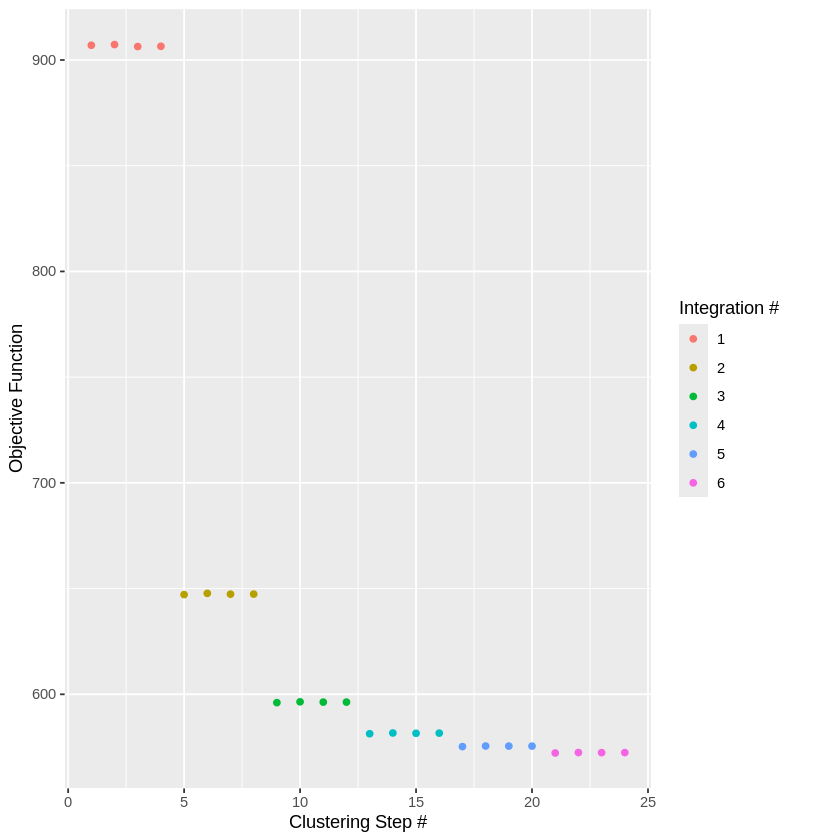

In [ ]:
# Define outputDir at the beginning to avoid 'object not found' errors
outputDir <- getwd()

harmony_processed <- RunHarmony(seurat_processed, c("Sample"), plot_convergence = TRUE)

harmony_processed <- RunUMAP(harmony_processed, reduction = "harmony", dims = 1:50)

harmony_processed <- FindNeighbors(harmony_processed, reduction = "harmony", dims = 1:50, graph.name = "harmony_nn")

# Note: 'group.name' was corrected to 'cluster.name' for FindClusters
harmony_processed <- FindClusters(harmony_processed, graph.name = "harmony_nn", resolution = 0.8, cluster.name = "Harmony_clusters")

# Save the corrected RDS
saveRDS(harmony_processed, file = file.path(outputDir, "04_GSE183276_harmony_corrected.rds"))

merged1 = JoinLayers(harmony_processed)
sce_harmony <- as.SingleCellExperiment(merged1, assay = "RNA")

h5seurat_name1 <- "04_GSE183276_harmony_corrected.h5seurat"
h5ad_name1 <- "04_GSE183276_harmony_corrected.h5ad"

SaveH5Seurat(
  object = harmony_processed,
  filename = file.path(outputDir, h5seurat_name1),
  overwrite = TRUE,
  version = "3"
)

writeH5AD(sce_harmony, file = file.path(outputDir, h5ad_name1))

<ggplot2::labels> List of 1
 $ title: chr "Uncorrected"

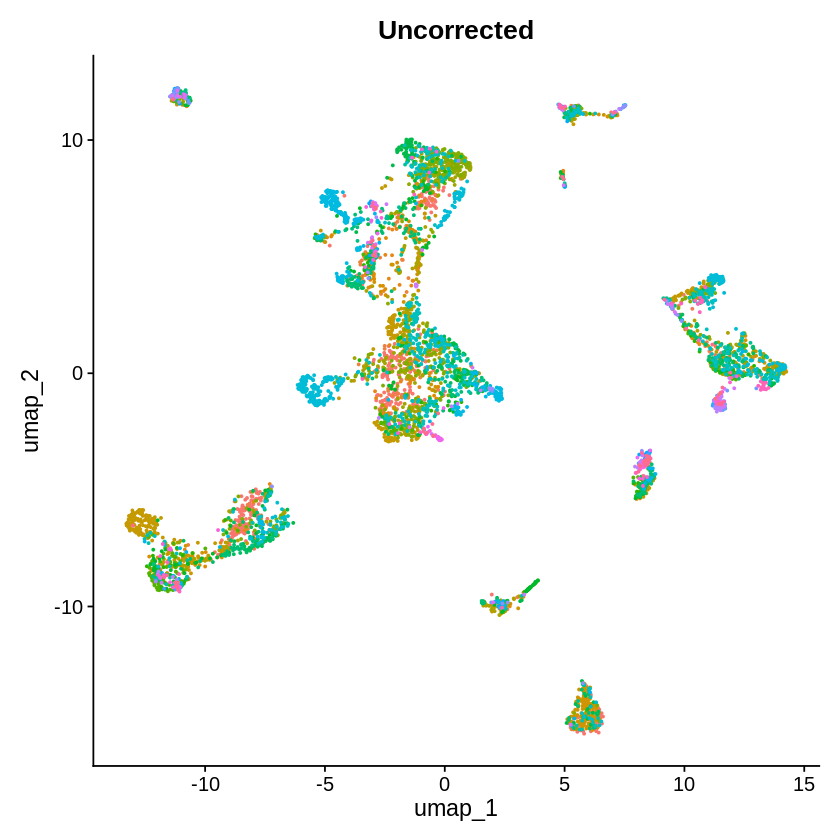

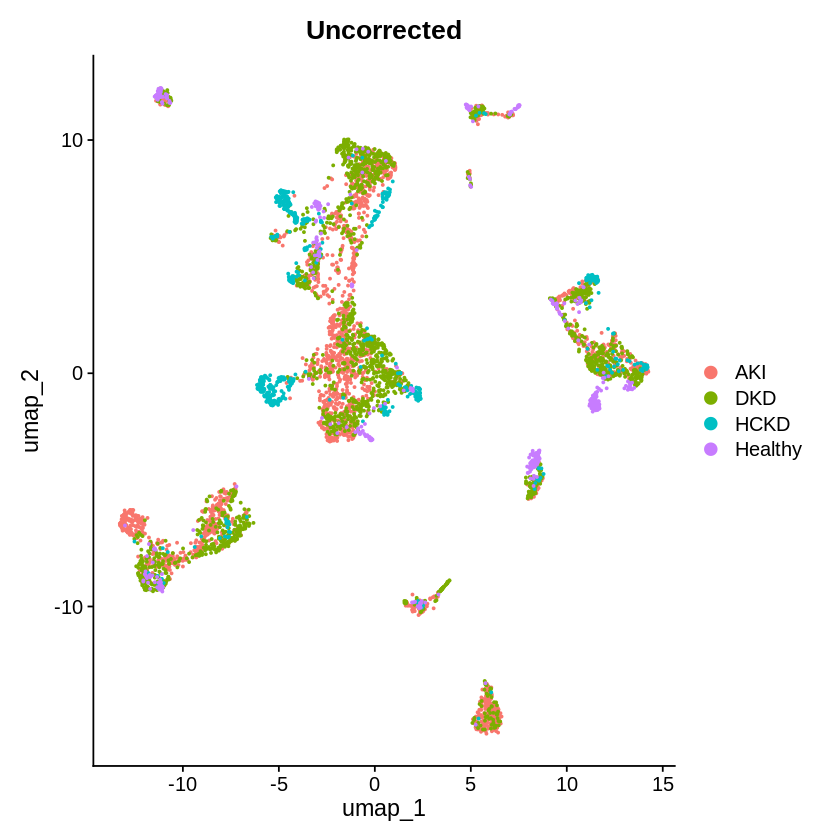

In [ ]:
p <- DimPlot(seurat_processed, reduction = "umap", group.by = "Sample") + ggtitle("Uncorrected") +  NoLegend()
  ggtitle("Uncorrected")
ggsave(filename = file.path(plotDir, "BENCHMARKING_GSE183276_RawPCA_sample.png"), width = 7, height = 6, dpi = 600)
p

p <-DimPlot(seurat_processed, reduction = "umap", group.by = "Condition") +
  ggtitle("Uncorrected")
ggsave(filename = file.path(plotDir, "BENCHMARKING_GSE183276_RawPCA_condition.png"), width = 8, height = 6, dpi = 600)
p

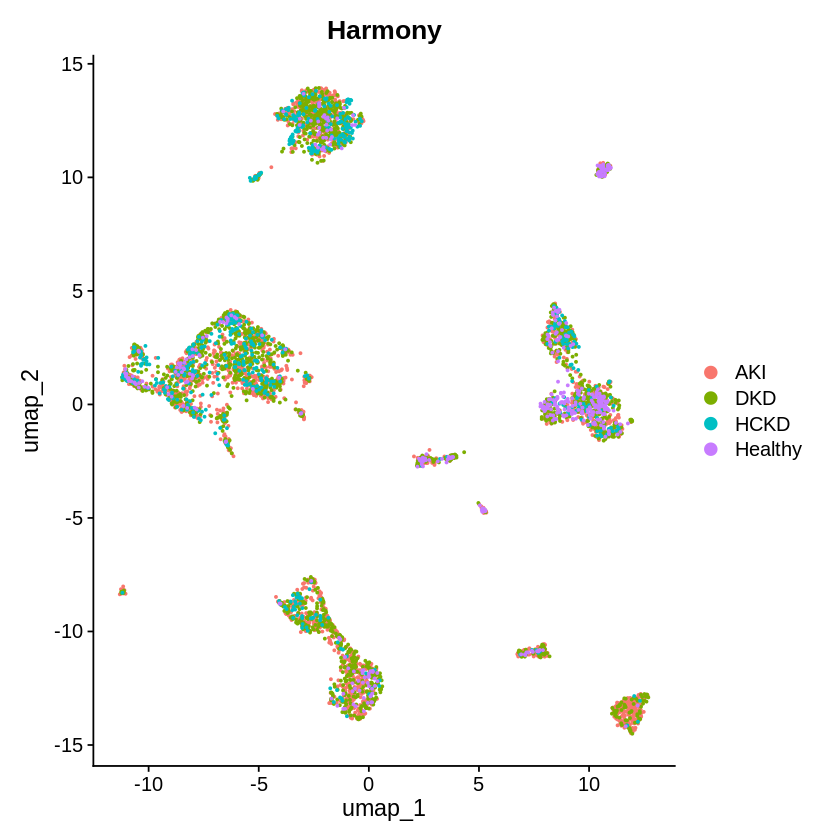

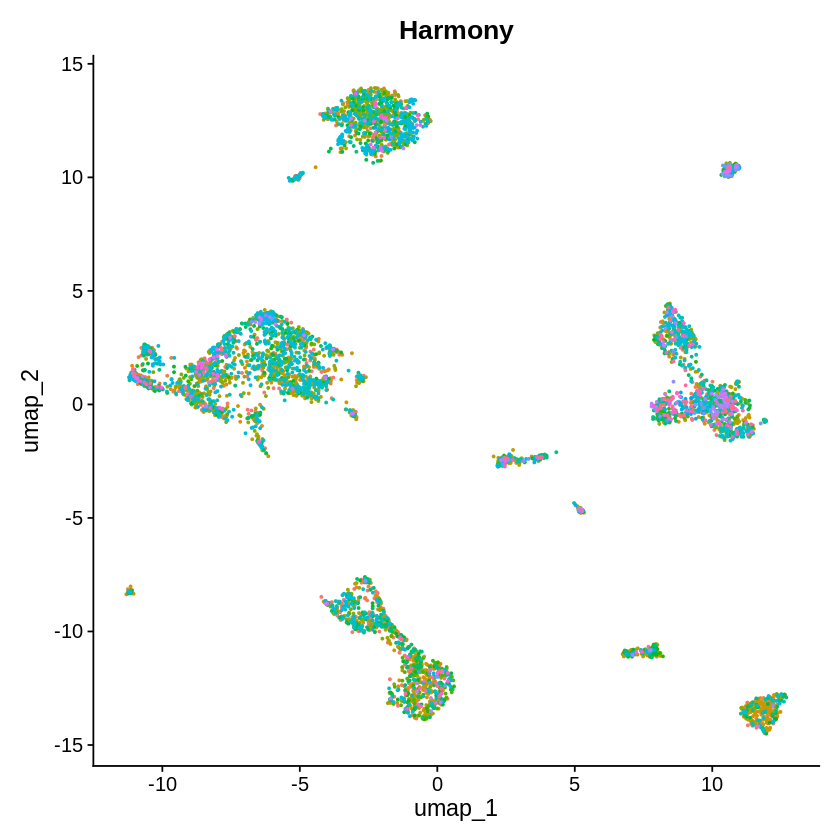

In [ ]:
p2 <-DimPlot(harmony_processed, reduction = "umap", group.by = "Condition") + ggtitle("Harmony")
ggsave(filename = file.path(plotDir, "BENCHMARKING_GSE183276_Harmony_condition.png"), width = 8, height = 6, dpi = 600)
p2

p <- DimPlot(harmony_processed, reduction = "umap", group.by = "Sample") + ggtitle("Harmony") +  NoLegend()
ggsave(filename = file.path(plotDir, "BENCHMARKING_GSE183276_Harmony_sample.png"), width = 7, height = 6, dpi = 600)
p

umap_hcoords <- Embeddings(harmony_processed, "umap")
write.csv(umap_hcoords, file="GSE183276_umap_coordinates.csv")

In [ ]:
# Pure R code to generate the Rmd file
rmd_filename <- "GSE183276_Analysis.Rmd"

rmd_header <- c(
  "---",
  "title: 'GSE183276 Single-cell RNA-seq Analysis'",
  "author: 'Colab User'",
  "date: '`r Sys.Date()`'",
  "output: html_document",
  "---",
  "",
  "# Setup",
  "```{r}",
  "library(Seurat)",
  "library(harmony)",
  "library(ggplot2)",
  "```",
  "",
  "# Load Data",
  "```{r}",
  "# Load the filtered Seurat object produced in this session",
  "seurat_processed <- readRDS('04_GSE183276_harmony_corrected.rds')",
  "```",
  "",
  "# Dimensionality Reduction Visualization",
  "```{r}",
  "DimPlot(seurat_processed, reduction = 'umap', group.by = 'Condition') + ggtitle('UMAP by Condition')",
  "DimPlot(seurat_processed, reduction = 'umap', group.by = 'Harmony_clusters') + ggtitle('UMAP by Clusters')",
  "```"
)

writeLines(rmd_header, rmd_filename)
cat("Successfully created:", rmd_filename, "\nYou can download it from the files sidebar.")

Successfully created: GSE183276_Analysis.Rmd 
You can download it from the files sidebar.

In [ ]:
# Placeholder cell - Rmd generation handled above
print("Rmd generation script updated to pure R.")

[1] "Rmd generation script updated to pure R."
